# BONUS EXERCISE

In [ ]:
from profilers import profile_cpu

### To retrieve the CPU usage percentage per core for the diffusion codes

In [ ]:
@profile_cpu(interval=1)
def evolve(grid, dt, D=1.0):
    xmax, ymax = grid_shape
    new_grid = [[0.0] * ymax for x in range(xmax)]
    for i in range(xmax):
        for j in range(ymax):
            grid_xx = (
                grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
            )
            grid_yy = (
                grid[i][(j + 1) % ymax] + grid[i][(j - 1) % ymax] - 2.0 * grid[i][j]
            )
            new_grid[i][j] = grid[i][j] + D * (grid_xx + grid_yy) * dt
    return new_grid
def run_experiment(num_iterations):
    # Setting up initial conditions 
    xmax, ymax = grid_shape
    grid = [[0.0] * ymax for x in range(xmax)]

    # These initial conditions are simulating a drop of dye in the middle of our
    # simulated region
    block_low = int(grid_shape[0] * 0.4)
    block_high = int(grid_shape[0] * 0.5)
    for i in range(block_low, block_high):
        for j in range(block_low, block_high):
            grid[i][j] = 0.005

    # Evolve the initial conditions
    for i in range(num_iterations):
        grid = evolve(grid, 0.1)

The profile_cpu decorator wraps the evolve function

Every time evolve() is called, CPU usage is measured

What happens on each call to evolve

1. Before evolve starts

 - A global CPUProfiler is fetched (or created)

 - A background thread starts running

2. While evolve runs

- every 1 second, it samples:

- CPU usage per core

- Current timestamp

4. After evolve finishes

- The profiler thread is stopped

- The collected samples are kept in memory

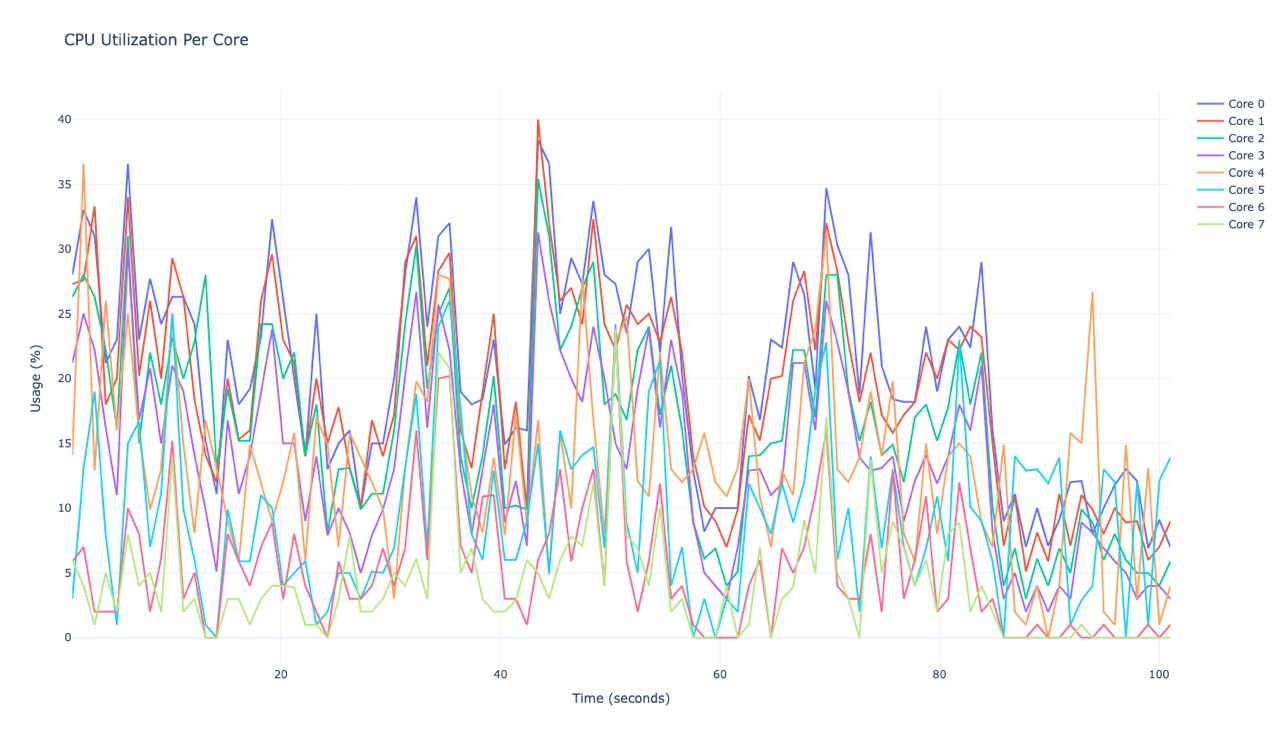

### While the diffusion code is running, the CPU is working steadily but not very hard. All cores show some activity, but none of them are fully used

Note: The Jupyter notebook was unable to run successfully due to certain dependencies that could not be migrated to the notebook environment. As a result, the code execution fails within Jupyter. For the complete and working implementation, please refer to the code provided in the accompanying ZIP file.

### The table shows the summary of the CPU usage


|   Time (s) |   Core 0 |   Core 1 |   Core 2 |   Core 3 |   Core 4 |   Core 5 |   Core 6 |   Core 7 |
|-------------|----------|----------|----------|----------|----------|----------|----------|----------|
|       1.01 |     28   |     27.3 |     26.3 |     21.2 |     14.1 |      3   |      5.9 |      6   |
|       2.01 |     33   |     27.6 |     28   |     25   |     36.6 |     13   |      7   |      4   |
|       3.03 |     31   |     33.3 |     26.3 |     22.2 |     12.9 |     19   |      2   |      1   |
|       4.04 |     21.2 |     18   |     22.2 |     16.2 |     26   |      7.9 |      2   |      5   |
|       5.05 |     23   |     20   |     16.2 |     11   |     16   |      1   |      2   |      2   |
|       6.06 |     36.6 |     34   |     31   |     30   |     25   |     15   |     10   |      8   |
|       7.07 |     23   |     20.2 |     15   |     16.8 |     15.8 |     16.7 |      8   |      4   |
|       8.08 |     27.7 |     26   |     22   |     20.8 |      9.9 |      7   |      2   |      5   |
|       9.09 |     24.2 |     20   |     18   |     15   |     13   |     11.1 |      6.1 |      2   |
|      10.1  |     26.3 |     29.3 |     23.2 |     21   |     25   |     25   |     15.2 |     13.9 |
|      11.11 |     26.3 |     26.3 |     20   |     19   |     14.9 |      9.9 |      3   |      2   |
|      12.12 |     24.2 |     18.4 |     22.8 |     14.1 |      8.1 |      6   |      5   |      3   |
|      13.13 |     15.2 |     14.1 |     28   |      9.9 |     16.8 |      1   |      0   |      0   |
|      14.14 |     11.1 |     12   |     13   |      5.1 |     13.1 |      0   |      0   |      0   |
|      15.15 |     23   |     20   |     19.2 |     16.8 |      9   |      9.9 |      8   |      3   |
|      16.16 |     18   |     15.3 |     15.2 |     11.1 |      5.9 |      5.9 |      5.9 |      3   |
|      17.17 |     19.2 |     16   |     15.2 |     14   |     14.9 |      5.9 |      4   |      1   |
|      18.18 |     23.2 |     26   |     24.2 |     19   |     12   |     11   |      7   |      3   |
|      19.19 |     32.3 |     29.6 |     24.2 |     23.8 |      9   |     10   |      8.9 |      4   |
|      20.2  |     26   |     23   |     20   |     15   |     12   |      4   |      3   |      4   |
|      21.21 |     20   |     21.2 |     22   |     15   |     15.8 |      5   |      8   |      3.9 |
|      22.22 |     14   |     14   |     14.1 |      9   |      5.9 |      5.9 |      4   |      1   |
|      23.23 |     25   |     20   |     18   |     14   |     17   |      1   |      2   |      1   |
|      24.24 |     13   |     15   |      8.1 |      7.9 |     14.9 |      2   |      0   |      0   |
|      25.25 |     15   |     17.8 |     13   |     10   |      7   |      5   |      5.9 |      3   |
|      26.26 |     16   |     13.1 |     13.1 |      8.1 |     15.8 |      5   |      3   |      7.9 |
|      27.27 |     10   |     10.1 |      9.9 |      5   |     13.9 |      3   |      3   |      2   |
|      28.28 |     15   |     16.8 |     11.1 |      7.9 |     12   |      5.1 |      4   |      2   |
|      29.29 |     15   |     14   |     11.1 |      9.9 |      9.9 |      5   |      6.9 |      3   |
|      30.3  |     20   |     17.2 |     16   |     13   |      3   |      6.9 |      4   |      5   |
|      31.31 |     28   |     29   |     24.2 |     20.2 |     13   |     13.1 |      6.9 |      4   |
|      32.33 |     34   |     31   |     30.3 |     26.7 |     19.8 |     18.8 |     16   |      6.1 |
|      33.33 |     24   |     21   |     19.2 |     16.2 |     18.2 |      7   |      6   |      3   |
|      34.34 |     31   |     28.3 |     25   |     25.7 |     28   |     24   |     20   |     22   |
|      35.35 |     32   |     29.7 |     27   |     22.2 |     27.7 |     26   |     20.2 |     20.8 |
|      36.36 |     19   |     16   |     14   |     13   |     16.8 |     17.8 |      7.1 |      5   |
|      37.37 |     18   |     13.1 |     10   |      8   |     11   |      8   |      5   |      6.9 |
|      38.38 |     18.4 |     19   |     14.1 |     13   |      8.1 |      6   |     10.9 |      3   |
|      39.38 |     23   |     25   |     20.2 |     18   |     13.9 |     12.9 |     11   |      2   |
|      40.39 |     14.9 |     13   |     10   |      8.9 |      7.9 |      6   |      3   |      2   |
|      41.4  |     16.2 |     18.2 |     10.2 |     12.1 |     17.3 |      6   |      3   |      2.9 |
|      42.41 |     16   |     10   |      9.9 |      7.1 |      8.8 |      9   |      1   |      6   |
|      43.42 |     38.4 |     40   |     35.4 |     31.3 |     16.8 |     15   |      6   |      5   |
|      44.42 |     36.6 |     32   |     31   |     26   |      5   |      4.9 |      8   |      3   |
|      45.43 |     25   |     26   |     22.2 |     22.2 |     15.8 |     16   |     13   |      6   |
|      46.44 |     29.3 |     27   |     24   |     20   |     10   |     13   |      5.9 |      7.8 |
|      47.45 |     27.3 |     24.2 |     27   |     18.2 |     27.7 |     14.1 |     10   |      7.1 |
|      48.46 |     33.7 |     32.3 |     29   |     24   |     16.8 |     14.7 |     13   |     11.9 |
|      49.47 |     28   |     24.2 |     18   |     20   |      8   |      6.9 |      4   |      4   |
|      50.48 |     27.3 |     22.2 |     18.8 |     15   |     22.8 |     24.2 |     24   |     23.8 |
|      51.49 |     23.5 |     25.7 |     16.8 |     13   |     24.8 |      8.9 |      5.9 |      7.9 |
|      52.5  |     29   |     24.2 |     22.2 |     19.2 |     12.1 |      5   |      2   |      6.9 |
|      53.52 |     30   |     25   |     24   |     23.8 |     10.9 |     19   |      5.9 |      4   |
|      54.53 |     22   |     22.8 |     17.2 |     16.2 |     22   |     21.4 |     11.9 |     10   |
|      55.54 |     31.7 |     26.3 |     21   |     23   |     13   |      4   |      3   |      2   |
|      56.55 |     20.2 |     22   |     16   |     18.8 |     12   |      7   |      4   |      3   |
|      57.56 |     12.9 |     14   |      8.9 |      9   |     13   |      0   |      1   |      0   |
|      58.57 |      8.2 |     10.1 |      6.1 |      5   |     15.8 |      3   |      0   |      0   |
|      59.58 |     10   |      9   |      6.9 |      4   |     12   |      0   |      0   |      0   |
|      60.6  |     10   |      7   |      4   |      3   |     10.9 |      3   |      0   |      4   |
|      61.61 |     10   |      9.9 |      5.1 |      7   |     13.1 |      2   |      0   |      0   |
|      62.62 |     20.2 |     17.2 |     14   |     12.9 |     20   |     11.9 |      4   |      1   |
|      63.63 |     16.8 |     15.2 |     14.1 |     13   |     10.9 |     10   |      6   |      7   |
|      64.64 |     23   |     20   |     15   |     11   |      7   |      8   |      0   |      0   |
|      65.65 |     22.4 |     20.2 |     15.2 |     11.9 |     12.9 |     11.9 |      6.9 |      3   |
|      66.66 |     29   |     26   |     22.2 |     21.2 |     11   |      8.9 |      5   |      3.9 |
|      67.66 |     26.5 |     28.3 |     22.2 |     21.2 |     21.2 |     12   |      7   |      9.1 |
|      68.67 |     19.2 |     22.2 |     17   |     16   |     23.8 |     19.2 |     11   |      5   |
|      69.68 |     34.7 |     32   |     28   |     26   |     31.3 |     22.8 |     16   |     17   |
|      70.69 |     30.3 |     28.3 |     28   |     22.8 |     13   |      6   |      4   |      5   |
|      71.7  |     28   |     22.8 |     19   |     19   |     12   |     10   |      3   |      3   |
|      72.71 |     18.8 |     18.2 |     15.2 |     13.9 |     13.9 |      2   |      3   |      0   |
|      73.72 |     31.3 |     22   |     18.2 |     12.9 |     19   |     14   |      8   |     13.7 |
|      74.73 |     21   |     17.2 |     14.1 |     13.1 |     14   |      6.9 |      2   |      5   |
|      75.74 |     18.4 |     15.8 |     14.9 |     14   |     19.8 |     13   |     12.9 |      9   |
|      76.75 |     18.2 |     17.2 |     12   |      9   |      8   |      7   |      3   |      6.9 |
|      77.76 |     18.2 |     18.2 |     17   |     12.1 |      5.9 |      4   |      6   |      4   |
|      78.77 |     24   |     22   |     18   |     14.1 |     15   |      6.9 |     10.9 |      6   |
|      79.77 |     19   |     20   |     15.2 |     11.9 |      8   |     10.9 |      2   |      2   |
|      80.78 |     23   |     23   |     17.8 |     14   |     14   |      5.9 |      3   |      8   |
|      81.8  |     24   |     22.2 |     22.8 |     18   |     15   |     23   |     12   |      8.9 |
|      82.81 |     22.4 |     24   |     18   |     16   |     14   |     10.1 |      6.9 |      2   |
|      83.82 |     29   |     23.2 |     22   |     21   |      8.9 |      9   |      2   |      4   |
|      84.83 |     16   |     15   |     10.1 |      8.1 |      7   |      5.9 |      3   |      2   |
|      85.84 |      9   |      7.1 |      4   |      3   |     14.9 |      0   |      0   |      0   |
|      86.85 |     11.1 |     10.9 |      6.9 |      5   |      2   |     14   |      0   |      0   |
|      87.87 |      7   |      5.1 |      3   |      2   |      1   |     12.9 |      0   |      0   |
|      88.88 |     10   |      8.1 |      6.1 |      4   |      4   |     13   |      1   |      0   |
|      89.89 |      7.1 |      5.9 |      4   |      2   |      0   |     11.9 |      0   |      0   |
|      90.91 |      9.1 |     11.1 |      6.9 |      4   |      4   |     13.9 |      0   |      0   |
|      91.92 |     12   |      7.1 |      5   |      3   |     15.8 |      1   |      1   |      0   |
|      92.93 |     12.1 |     11   |      9.9 |      8.9 |     15   |      2.9 |      0   |      1   |
|      93.94 |      8   |      9.9 |      8.9 |      8.1 |     26.7 |      4   |      0   |      0   |
|      94.95 |     10   |      8   |      6   |      6.9 |      2   |     13   |      1   |      0   |
|      95.96 |     11.8 |     10   |      8   |      5.9 |      1   |     12   |      0   |      0   |
|      96.98 |     13   |      8.9 |      6   |      5   |     14.9 |      0   |      0   |      0   |
|      97.99 |     12.1 |      9   |      5   |      3   |      3   |     12   |      0   |      0   |
|      99    |      6.9 |      6   |      5   |      4   |     13.1 |      1   |      1   |      0   |
|     100.02 |      9.1 |      7   |      4   |      4   |      1   |     12.1 |      0   |      0   |
|     101.03 |      7   |      9   |      5.9 |      3   |      4   |     13.9 |      1   |      0   |

The table shows that the diffusion simulation keeps the CPU moderately busy over time, with work spread unevenly across the cores. A few cores consistently do more work, while others remain lightly used or idle. This indicates that the computation is heavy but largely runs in a single-threaded manner, with limited parallel execution.